This notebook is to analyze the residuals resulting in Root-mean-square deviation RMSD as a measure of the goodness of fit.

In [2]:
import pandas as pd
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
import csv

In [50]:
base_path = Path('C:\\Users\\thinkBookUser\\Desktop\\Screening_Data_Analyzed')
#base_path = Path('K:\\SurfDrive\\')
resultpath = Path(base_path, '2019','11','07','chemical','results')
resultfile = 'B6_tau.csv'
fitfile = 'B6_fit.csv'
fit = pd.read_csv(Path(resultpath,fitfile))
lifetimetraces = np.loadtxt(Path(resultpath,resultfile))
frameinterval = 5
forskendpoint = True
nroi = lifetimetraces.shape[0]
ntime = lifetimetraces.shape[1]

In [51]:
fit.head()

,Unnamed: 0,start(ns),range(ns),breakdown_time(s),midpoint(s),start tau(ns),e_start,e_range,e_breakdown_time,e_midpoint,error,condition
0,0,3.135354,-0.866864,42.973783,107.388601,2.289345,0.033604,0.036330,4.053300,1.332016,0.0,PDE6D
1,1,3.182378,-0.797623,26.120120,130.228978,2.414674,0.014196,0.017778,2.667100,0.767576,0.0,PDE6D
2,2,3.210812,-0.761180,58.117372,155.989492,2.566047,0.018031,0.031413,6.781535,1.797631,1.0,PDE6D
3,3,3.172855,-0.855058,42.947880,104.871836,2.297263,0.022531,0.024091,2.541972,0.869466,0.0,PDE6D
4,4,3.123591,-0.840043,34.717245,104.791271,2.270759,0.017983,0.019338,2.055664,0.651578,0.0,PDE6D


In [52]:
fit_sel = fit[fit['breakdown_time(s)'] > 10]
fit_sel = fit_sel[fit_sel['error']==0]
fit_sel.head()

,Unnamed: 0,start(ns),range(ns),breakdown_time(s),midpoint(s),start tau(ns),e_start,e_range,e_breakdown_time,e_midpoint,error,condition
0,0,3.135354,-0.866864,42.973783,107.388601,2.289345,0.033604,0.036330,4.053300,1.332016,0.0,PDE6D
1,1,3.182378,-0.797623,26.120120,130.228978,2.414674,0.014196,0.017778,2.667100,0.767576,0.0,PDE6D
3,3,3.172855,-0.855058,42.947880,104.871836,2.297263,0.022531,0.024091,2.541972,0.869466,0.0,PDE6D
4,4,3.123591,-0.840043,34.717245,104.791271,2.270759,0.017983,0.019338,2.055664,0.651578,0.0,PDE6D
5,5,3.156838,-0.804747,40.507075,117.242543,2.346713,0.016207,0.018503,2.717995,0.802973,0.0,PDE6D


In [53]:
def fit_function(x, a, b, c, d):
    return a + b / (1 + np.exp(-4 * (x - d)/c)) 

In [54]:
trace_id = 4
fit_vals= fit.loc[trace_id,:]
fit_vals

Unnamed: 0                   4
start(ns)              3.12359
range(ns)            -0.840043
breakdown_time(s)      34.7172
midpoint(s)            104.791
start tau(ns)          2.27076
e_start              0.0179829
e_range              0.0193382
e_breakdown_time       2.05566
e_midpoint            0.651578
error                        0
condition                PDE6D
Name: 4, dtype: object

In [55]:
xdat = np.arange(0, ntime * frameinterval, frameinterval)
print(xdat)
print('n_x =', len(xdat))

[  0   5  10  15  20  25  30  35  40  45  50  55  60  65  70  75  80  85
  90  95 100 105 110 115 120 125 130 135 140 145 150 155 160 165 170 175
 180 185 190 195 200 205 210 215 220 225 230 235 240 245 250 255 260 265
 270 275 280 285 290 295 300 305]
n_x = 62


In [56]:
ydat = lifetimetraces[trace_id]
print(ydat)
print('n_y =', len(ydat))

[2.23320738 2.2584033  2.26595277 2.28395136 2.27472846 2.25336134
 2.29275362 2.45389188 2.63710876 2.79458715 2.91311943 2.99068534
 3.00117376 3.04957055 3.09197513 3.079446   3.11616668 3.03864021
 3.01707081 2.90728858 2.84882956 2.74134566 2.59161816 2.50414322
 2.40813309 2.38255578 2.34190231 2.33829602 2.28827216 2.28248705
 2.24876293 2.25119197 2.27513711 2.31440037 2.27931561 2.28662103
 2.27179807 2.26762195 2.2958054  2.30954032 2.28945687 2.29742721
 2.29024128 2.27241594 2.27711646 2.28511008 2.31065662 2.30866469
 2.26916514 2.35176793 2.43082493 2.57919382 2.66918823 2.6963088
 2.83561214 2.86672918 2.92216312 2.9656496  2.97824466 2.98988168
 3.00864218 3.01708594]
n_y = 62


In [57]:
yfit = fit_function(xdat,fit_vals['start(ns)'],fit_vals['range(ns)'],fit_vals['breakdown_time(s)'],fit_vals['midpoint(s)'])
print(yfit)
print('n_yfit =', len(yfit))

[3.1235866  3.12358286 3.12357622 3.1235644  3.12354337 3.12350595
 3.1234394  3.12332103 3.12311052 3.12273627 3.12207129 3.12089084
 3.11879897 3.11510313 3.10860824 3.09730085 3.07793232 3.04566126
 2.99429399 2.91819349 2.81664595 2.69851982 2.58118734 2.48157508
 2.40767163 2.35814438 2.32717513 2.30864166 2.29784036 2.29164234
 2.28811744 2.28612296 2.28499768 2.28436384 2.28400714 2.28380651
 2.28369369 2.28363027 2.28359461 2.28357457 2.2835633  2.28355697
 2.28355341 2.2835514  2.28355028 2.28354965 2.28354929 2.28354909
 2.28354898 2.28354892 2.28354888 2.28354886 2.28354885 2.28354884
 2.28354884 2.28354884 2.28354884 2.28354884 2.28354884 2.28354884
 2.28354884 2.28354884]
n_yfit = 62


In [58]:
#y_sigma = np.random.random(len(ydat))
#print(y_sigma)
#print('n_ysigma =', len(y_sigma))

In [59]:
# find the fit-range
fitrange = np.zeros(shape=2, dtype=int)
mean_trace = np.mean(lifetimetraces, axis=0)

d_mean_trace = np.diff(mean_trace)
fitrange[0] = np.argmax(mean_trace[0:int(150 / frameinterval)])  # maximum in the first 150 seconds
fitrange[1] = ntime
if forskendpoint:
    # 3 frames before maximum increase after peak.
    fitrange[1] = fitrange[0] + np.argmax(d_mean_trace[fitrange[0]:]) - 1

xdat_selected = xdat[fitrange[0]:fitrange[1]]
ydat_selected = ydat[fitrange[0]:fitrange[1]]
yfit_selected = yfit[fitrange[0]:fitrange[1]]
#y_sigma_selected = y_sigma[fitrange[0]:fitrange[1]]

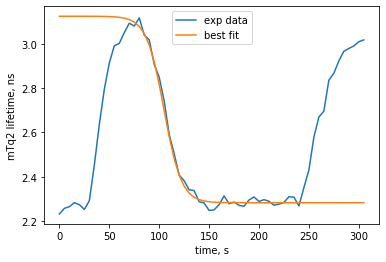

In [60]:
plt.xlabel("time, s")
plt.ylabel("mTq2 lifetime, ns")
plt.plot(xdat,ydat, label="exp data")
plt.plot(xdat,yfit, label="best fit")
plt.legend()
#chisq = sum(((ydat_selected-yfit_selected)/y_sigma_selected)**2)
#plt.figtext(0.42, 0.69, "chi-square: %.0f"%chisq)
#n = len(ydat_selected)
#plt.figtext(0.42, 0.63, "n: %.0f"%n)
#fit_vals
# NB: since we do not have experimental values in multiplicates, we cannot divide by actual sigma!
# Hence we cannot use chi-sq!
# In this example I use generated noise y_sigma (between 0 and 1 ns for every exp. tau value)

In [61]:
yresid = ydat - yfit
print(yresid)

[-8.90379215e-01 -8.65179563e-01 -8.57623454e-01 -8.39613038e-01
 -8.48814908e-01 -8.70144608e-01 -8.30685778e-01 -6.69429143e-01
 -4.86001759e-01 -3.28149123e-01 -2.08951856e-01 -1.30205503e-01
 -1.17625202e-01 -6.55325746e-02 -1.66331173e-02 -1.78548546e-02
  3.82343609e-02 -7.02104817e-03  2.27768114e-02 -1.09049171e-02
  3.21836081e-02  4.28258431e-02  1.04308251e-02  2.25681408e-02
  4.61453107e-04  2.44114057e-02  1.47271801e-02  2.96543542e-02
 -9.56819776e-03 -9.15529223e-03 -3.93545040e-02 -3.49309891e-02
 -9.86057301e-03  3.00365268e-02 -4.69153076e-03  2.81452259e-03
 -1.18956254e-02 -1.60083147e-02  1.22107858e-02  2.59657507e-02
  5.89357012e-03  1.38702412e-02  6.68787286e-03 -1.11354645e-02
 -6.43381775e-03  1.56043338e-03  2.71073277e-02  2.51155958e-02
 -1.43838371e-02  6.82190147e-02  1.47276047e-01  2.95644959e-01
  3.85639382e-01  4.12759951e-01  5.52063304e-01  5.83180344e-01
  6.38614283e-01  6.82100761e-01  6.94695826e-01  7.06332844e-01
  7.25093344e-01  7.33537

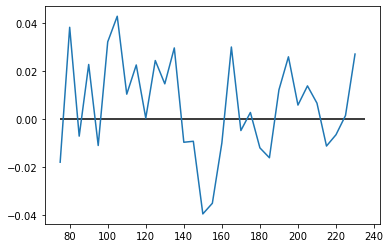

In [62]:
#here I tried to just plot the residuals between the xperimental values and the fitted values
plt.plot(xdat[fitrange[0]:fitrange[1]], yresid[fitrange[0]:fitrange[1]])
#plt.plot(x, yresid)
plt.hlines(0, frameinterval*fitrange[0], frameinterval*fitrange[1])

In [63]:
#  The residual sum of squares is used to help you decide if a statistical model is a good fit for your data. 
SSresid = sum(yresid[fitrange[0]:fitrange[1]]**2)
# The Total SS (TSS or SST) tells you how much variation there is in the dependent variable. SStotal = Σ((Yi – mean of Y)**2).
# or also people use: SStotal = n*var(Y)
SStotal = len(ydat[fitrange[0]:fitrange[1]]) * np.var(ydat)
Rsq = 1-(SSresid/SStotal)
print("SSresid = %.2f"%SSresid)
print("SStotal = %.2f"%SStotal)
print("Rsq = %.2f"%Rsq)
# this formula works in the more linear area of our curve, BUT
# but Kees pointed out, that we must use the variance in data aqusition, not of actual y values like is here in the formul

SSresid = 0.01
SStotal = 3.12
Rsq = 1.00


In [64]:
#The root-mean-square deviation (RMSD): sqrt(SSresid/n)
#With RMSD approaching zero the fit is approaching perfection
#In the paper we should define a small RMSD limit under which we claim our fit is excellen!

RMSD = np.sqrt(SSresid / len(ydat_selected))
print("RMSD = %.3f ns"%RMSD)

RMSD = 0.021 ns


In [65]:
#The mean absolute percentage error (MAPE), also known as mean absolute percentage deviation (MAPD),
#is a measure of prediction accuracy of a forecasting method in statistics, for example in trend estimation.
#It usually expresses the accuracy as a ratio defined by the formula:
# MAPE = (1/n) * Σ(|actual – forecast| / |actual|) * 100

# The smaller the error, again the better! Below 1% is a good measure for goodness of fit.

MAPE = (100/len(ydat_selected))*sum(abs(ydat_selected-yfit_selected) / ydat_selected)
print("MAPE = %.1f"%MAPE, "%")

#NB(limitation to MAPE if any datapoin = 0, because we cannot divide by zero)

MAPE = 0.7 %
